# Quick Exploratory Data Analysis

This notebook performs an initial data integrity and statistical exploration focused on building a trading model on the provided cryptocurrency panel dataset. The goal is to understand time-grid quality, missingness, basic return statistics and cross-asset relationships before feature engineering and modeling.

## Data loading and temporal integrity check

Before building any trading model, we need to verify that the dataset is ordered correctly and that each asset follows the expected 4-hour time grid. This matters because a forecasting model is only valid if observations are aligned in time and if lagged features are computed from truly past information.

In the next code cell, we load the dataset, parse the timestamp column, sort observations by asset and time, and check the number of assets, the dominant time interval, duplicate timestamps, irregular time gaps, and missing timestamps for each cryptocurrency.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew, kurtosis
from pathlib import Path


def resolve_data_path(filename='pr15_crypto.csv') -> Path:
    """Search upward from the current working directory to find the dataset file.
    This makes the notebook robust to different working directory locations.
    """
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Unable to locate {filename} from {Path.cwd().resolve()} upwards.")


# Robust loading of the dataset from the workspace
DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['Asset_ID', 'timestamp']).reset_index(drop=True)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Distinct assets: {df['Asset_ID'].nunique()}")

# Time-integrity check: observed frequency, duplicates and gaps
print('\n--- TIME INTEGRITY ANALYSIS ---')
gap_report = []

for asset_id, asset_data in df.groupby('Asset_ID'):
    asset_data = asset_data.sort_values('timestamp')
    asset_name = asset_data['Asset_Name'].iloc[0] if 'Asset_Name' in asset_data.columns else str(asset_id)

    # Use unique timestamps (drop exact duplicate timestamp rows)
    timestamps = asset_data['timestamp'].drop_duplicates()
    time_deltas = timestamps.diff().dropna()

    if time_deltas.empty:
        # not enough points to infer frequency
        continue

    # mode_delta: most common observed interval between consecutive timestamps
    mode_delta = time_deltas.mode().iloc[0]

    # Count exact duplicate timestamp rows (same timestamp appears multiple times)
    duplicate_timestamps = asset_data.duplicated(subset=['timestamp']).sum()

    # Build the expected regular index using the modal delta and compare
    expected_index = pd.date_range(start=timestamps.min(), end=timestamps.max(), freq=mode_delta)
    missing_timestamps = expected_index.difference(timestamps)

    # irregular_deltas counts how many consecutive differences are not equal to the modal interval
    irregular_deltas = (time_deltas != mode_delta).sum()

    gap_report.append({
        'Asset_ID': asset_id,
        'Asset_Name': asset_name,
        'Observed points': len(timestamps),
        'Expected points': len(expected_index),
        'Missing timestamps': len(missing_timestamps),
        'Missing share': len(missing_timestamps) / len(expected_index),
        'Duplicate timestamps': int(duplicate_timestamps),
        'Mode delta': mode_delta,
        'Irregular deltas': int(irregular_deltas)
    })

    print(f"Asset_ID {asset_id} ({asset_name}): mode={mode_delta}, duplicates={duplicate_timestamps}, irregular_deltas={irregular_deltas}, missing_timestamps={len(missing_timestamps)}")

# Summarize top assets by missing timestamps for quick inspection
gap_report_df = pd.DataFrame(gap_report).sort_values(['Missing timestamps', 'Irregular deltas'], ascending=False)
print('\nTop assets by missing timestamps:')
print(gap_report_df[['Asset_ID', 'Asset_Name', 'Mode delta', 'Observed points', 'Expected points', 'Missing timestamps', 'Missing share', 'Duplicate timestamps', 'Irregular deltas']].head(10).to_string(index=False))

Dataset loaded from: /Users/typ4ndi3_/Desktop/All I Need/Nova SBE/Courses/Introduction to Machine Learning/Project/Cryptocurrency/Machine-Learning-Group-Poject/pr15_crypto.csv
Rows: 104,324 | Columns: 12 | Distinct assets: 14

--- TIME INTEGRITY ANALYSIS ---
Asset_ID 0 (Binance Coin): mode=0 days 04:00:00, duplicates=0, irregular_deltas=6, missing_timestamps=14
Asset_ID 1 (Bitcoin): mode=0 days 04:00:00, duplicates=0, irregular_deltas=0, missing_timestamps=0
Asset_ID 2 (Bitcoin Cash): mode=0 days 04:00:00, duplicates=0, irregular_deltas=0, missing_timestamps=0
Asset_ID 3 (Cardano): mode=0 days 04:00:00, duplicates=0, irregular_deltas=0, missing_timestamps=0
Asset_ID 4 (Dogecoin): mode=0 days 04:00:00, duplicates=0, irregular_deltas=1, missing_timestamps=2
Asset_ID 5 (EOS.IO): mode=0 days 04:00:00, duplicates=0, irregular_deltas=0, missing_timestamps=0
Asset_ID 6 (Ethereum): mode=0 days 04:00:00, duplicates=0, irregular_deltas=0, missing_timestamps=0
Asset_ID 7 (Ethereum Classic): mode=

## Interpretation of the temporal integrity output

The dataset contains 104,324 rows and 14 assets. The dominant frequency is consistently 4 hours and there are no duplicate timestamps within each asset, which is good for a forecasting setup. However, the missingness is not uniform. Most assets have no or very few missing timestamps, while Maker has 3,727 missing timestamps, about 54.9% of its expected 4-hour grid. Stellar, Binance Coin, Monero, Dogecoin, and IOTA have only small gaps.

This suggests that the panel is mostly usable, but Maker is structurally different and should probably be excluded from the main model or handled separately in a robustness check. The next code cell investigates whether missing timestamps are shared across assets or concentrated in isolated long gaps. That distinction matters because shared missingness may indicate exchange-wide data problems, while asset-specific long gaps suggest an asset-level data quality issue.



Timestamps missing for multiple assets (top 20):
timestamp
2019-10-16 04:00:00    3
2019-03-12 04:00:00    2
2018-11-14 04:00:00    2
2019-10-16 00:00:00    2
2018-06-26 08:00:00    2
2018-07-04 04:00:00    2
2018-10-30 00:00:00    2
2018-08-23 08:00:00    2
2019-05-15 08:00:00    2
2019-10-30 04:00:00    1
2019-10-29 16:00:00    1
2019-10-29 20:00:00    1
2019-10-29 12:00:00    1
2019-10-29 08:00:00    1
2019-10-29 04:00:00    1
2019-10-29 00:00:00    1
2019-10-30 00:00:00    1
2018-02-08 04:00:00    1
2019-10-30 08:00:00    1
2019-10-28 20:00:00    1

Examples of long gaps (top 20 by gap steps):
 Asset_ID Asset_Name  Gap end  Gap steps     Gap duration
       10      Maker    77318        261 43 days 12:00:00
       10      Maker    77349        226 37 days 16:00:00
       10      Maker    77327        200 33 days 08:00:00
       10      Maker    77471        178 29 days 16:00:00
       10      Maker    77466        170 28 days 08:00:00
       10      Maker    77505        104 17 da

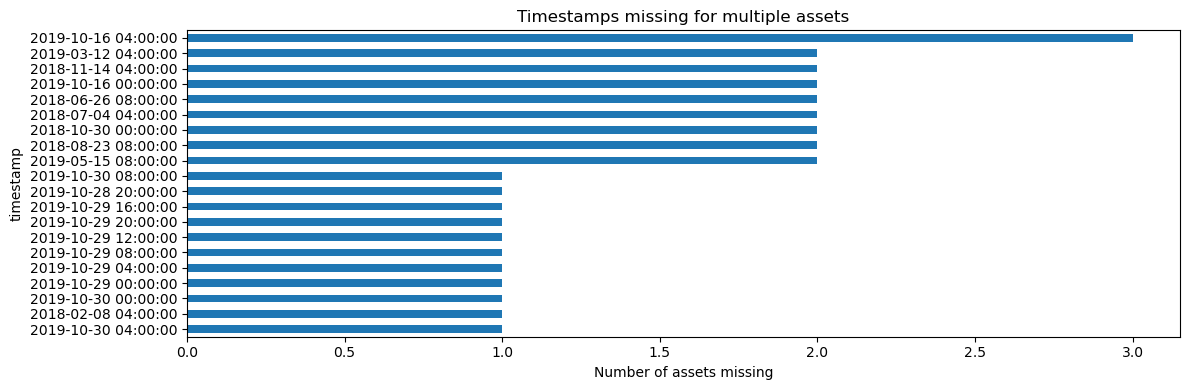

In [2]:
# Gap deep-dive: length, position and concentration across assets
EXPECTED_FREQ = pd.Timedelta(hours=4)  # grid consistent with the dominant observed granularity
gap_examples = []
all_missing_rows = []

for asset_id, asset_data in df.groupby('Asset_ID'):
    asset_data = asset_data.sort_values('timestamp')
    asset_name = asset_data['Asset_Name'].iloc[0] if 'Asset_Name' in asset_data.columns else str(asset_id)
    timestamps = asset_data['timestamp'].drop_duplicates()

    # Construct a full regular index using the expected 4-hour frequency
    full_index = pd.date_range(start=timestamps.min(), end=timestamps.max(), freq=EXPECTED_FREQ)
    missing_timestamps = full_index.difference(timestamps)

    # Collect missing timestamps for global inspection
    for missing_ts in missing_timestamps:
        all_missing_rows.append({'timestamp': missing_ts, 'Asset_ID': asset_id, 'Asset_Name': asset_name})

    # Compute actual diffs and count gaps that are multiples of the expected frequency
    diffs = timestamps.diff().dropna()
    gap_steps = (diffs / EXPECTED_FREQ).round().astype(int)
    large_gaps = gap_steps[gap_steps > 1]

    # Record examples of large gaps (more than one expected step)
    for gap_end_ts, steps in large_gaps.items():
        gap_examples.append({
            'Asset_ID': asset_id,
            'Asset_Name': asset_name,
            'Gap end': gap_end_ts,
            'Gap steps': int(steps),
            'Gap duration': steps * EXPECTED_FREQ
        })

missing_map_df = pd.DataFrame(all_missing_rows)
if not missing_map_df.empty:
    # Count how many assets are missing the same timestamp (synchronized missingness)
    shared_missing = missing_map_df.groupby('timestamp').size().sort_values(ascending=False)
    print('\nTimestamps missing for multiple assets (top 20):')
    print(shared_missing.head(20).to_string())
else:
    print('\nNo missing timestamps relative to the 4h reference grid.')

# Show examples of long gaps across assets
gap_examples_df = pd.DataFrame(gap_examples)
if not gap_examples_df.empty:
    print('\nExamples of long gaps (top 20 by gap steps):')
    print(gap_examples_df.sort_values('Gap steps', ascending=False).head(20).to_string(index=False))
else:
    print('\nNo long gaps found relative to the 4h grid.')

# Visualize the timestamps that are missing for multiple assets (if present)
if not missing_map_df.empty:
    plt.figure(figsize=(12, 4))
    shared_missing.head(20).sort_values().plot(kind='barh')
    plt.title('Timestamps missing for multiple assets')
    plt.xlabel('Number of assets missing')
    plt.tight_layout()
    plt.show()

## Interpretation of the gap deep-dive

The missing timestamps are only weakly synchronized across assets: the most common missing timestamp affects three assets, and most listed timestamps affect only one or two. The long-gap table shows that the largest gaps are entirely concentrated in Maker, with gaps lasting from several days to more than 40 days.

This means the missingness is mainly an asset-specific problem rather than a global timestamp problem. For the main trading model, we should exclude Maker before continuing with stationarity diagnostics and feature engineering. Keeping Maker would make the panel less comparable across assets, would complicate lagged and rolling features, and could force us to impute long multi-week gaps. That would be risky because interpolation would create artificial price paths and distort return dynamics.

In the next code cell, we therefore create a clean modeling dataset by removing Maker from the working dataframe. We keep a copy of the original dataset as `raw_df`, define Maker explicitly as the excluded asset, filter it out, and then re-check the number of rows, remaining assets, date range, and remaining timestamp gaps. All following EDA cells should use this filtered dataframe, because it is the dataset that will feed the trading-model pipeline.


In [3]:
print('\n--- MODELING DATASET CLEANING AFTER GAP ANALYSIS ---')

# Keep the original loaded dataset available, and make the filtering step idempotent.
# This lets us re-run this cell without repeatedly filtering an already-filtered dataframe.
if 'raw_df' not in globals():
    raw_df = df.copy()

EXCLUDED_ASSET_NAMES = ['Maker']
excluded_rows = raw_df[raw_df['Asset_Name'].isin(EXCLUDED_ASSET_NAMES)].copy()

# From this point onward, df is the modeling/EDA dataframe used by the next cells.
df = raw_df.loc[~raw_df['Asset_Name'].isin(EXCLUDED_ASSET_NAMES)].copy().reset_index(drop=True)

print(f'Rows before exclusion: {len(raw_df):,}')
print(f'Assets before exclusion: {raw_df["Asset_Name"].nunique()}')
print(f'Excluded assets: {", ".join(EXCLUDED_ASSET_NAMES)}')
print(f'Rows removed: {len(excluded_rows):,}')
print(f'Rows after exclusion: {len(df):,}')
print(f'Assets after exclusion: {df["Asset_Name"].nunique()}')
print(f'Date range after exclusion: {df["timestamp"].min()} -> {df["timestamp"].max()}')

print('\nRemaining assets:')
print(
    df[['Asset_ID', 'Asset_Name']]
    .drop_duplicates()
    .sort_values('Asset_ID')
    .to_string(index=False)
)

# Re-check temporal gaps on the filtered modeling dataset.
filtered_gap_report = []
expected_freq = pd.Timedelta(hours=4)

for asset_id, asset_data in df.groupby('Asset_ID'):
    asset_data = asset_data.sort_values('timestamp')
    asset_name = asset_data['Asset_Name'].iloc[0]
    timestamps = asset_data['timestamp'].drop_duplicates()
    expected_index = pd.date_range(timestamps.min(), timestamps.max(), freq=expected_freq)
    missing_timestamps = expected_index.difference(timestamps)
    time_deltas = timestamps.diff().dropna()

    filtered_gap_report.append({
        'Asset_ID': asset_id,
        'Asset_Name': asset_name,
        'Observed points': len(timestamps),
        'Expected points': len(expected_index),
        'Missing timestamps': len(missing_timestamps),
        'Missing share': len(missing_timestamps) / len(expected_index),
        'Irregular deltas': int((time_deltas != expected_freq).sum())
    })

filtered_gap_report_df = pd.DataFrame(filtered_gap_report).sort_values(
    ['Missing timestamps', 'Irregular deltas'], ascending=False
)

print('\nTemporal gaps after excluding Maker:')
print(filtered_gap_report_df.to_string(index=False))



--- MODELING DATASET CLEANING AFTER GAP ANALYSIS ---
Rows before exclusion: 104,324
Assets before exclusion: 14
Excluded assets: Maker
Rows removed: 3,067
Rows after exclusion: 101,257
Assets after exclusion: 13
Date range after exclusion: 2018-01-01 00:00:00 -> 2021-09-20 20:00:00

Remaining assets:
 Asset_ID       Asset_Name
        0     Binance Coin
        1          Bitcoin
        2     Bitcoin Cash
        3          Cardano
        4         Dogecoin
        5           EOS.IO
        6         Ethereum
        7 Ethereum Classic
        8             IOTA
        9         Litecoin
       11           Monero
       12          Stellar
       13             TRON

Temporal gaps after excluding Maker:
 Asset_ID       Asset_Name  Observed points  Expected points  Missing timestamps  Missing share  Irregular deltas
       12          Stellar             7856             7872                  16       0.002033                14
        0     Binance Coin             8140          

## Interpretation of the modeling dataset cleaning

After removing Maker, the working dataset contains 101,257 rows and 13 assets instead of 104,324 rows and 14 assets. This removes the only asset with severe long gaps while preserving the broad cross-section of cryptocurrencies. The remaining assets still cover the full project period where available, and their remaining missingness is small: the largest residual issue is Stellar with 16 missing timestamps, followed by Binance Coin with 14. These are minor compared with Maker's 3,727 missing timestamps.

This filtered dataset is a better basis for the main model because lagged returns, rolling volatility, and future-return targets can be computed with far less distortion. We are not claiming Maker is unusable forever; rather, we exclude it from the main experiment and can later mention it as a robustness limitation or separate analysis.

Now that the modeling dataframe is defined, the next step is to check stationarity on the same data that will be used for modeling. This is important because our planned trading model predicts whether the next 4-hour log return is positive, so we need to justify using return-based features rather than raw price levels.



--- RIGOROUS STATIONARITY DIAGNOSTICS ---
ADF H0: unit root. KPSS H0: stationarity around the chosen deterministic terms.
ADF lag length is selected with BIC, not the default AIC.
Stationarity diagnostics are run on the filtered modeling dataset: 13 assets, 101,257 rows.


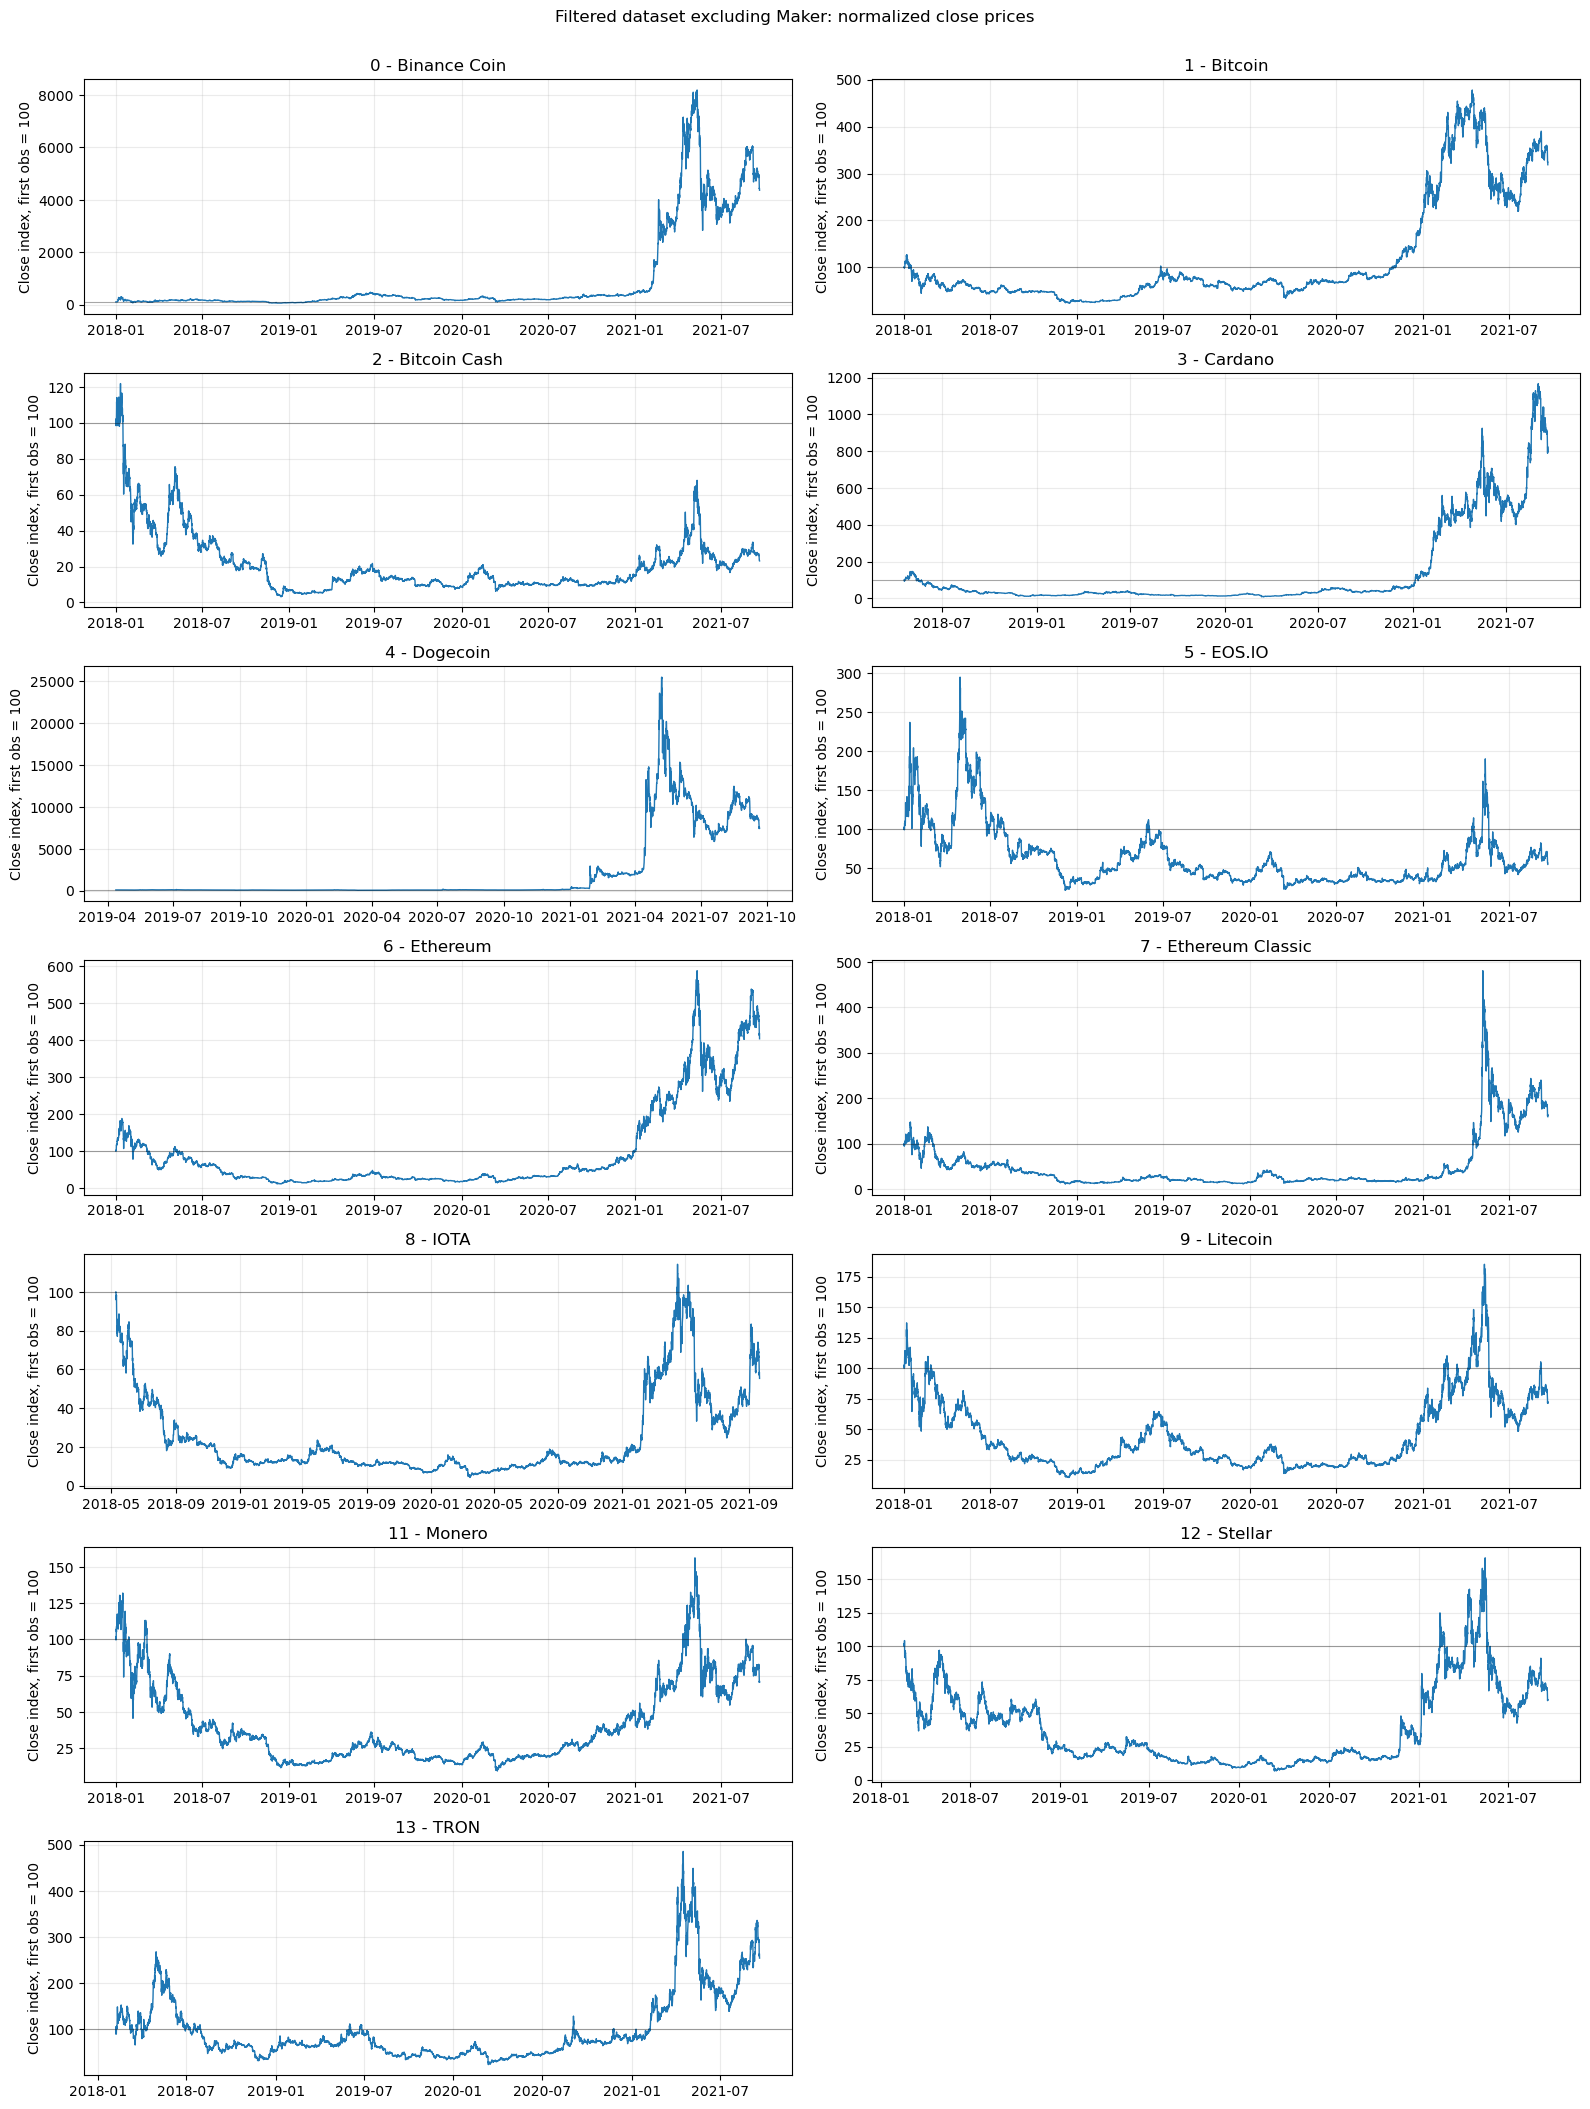

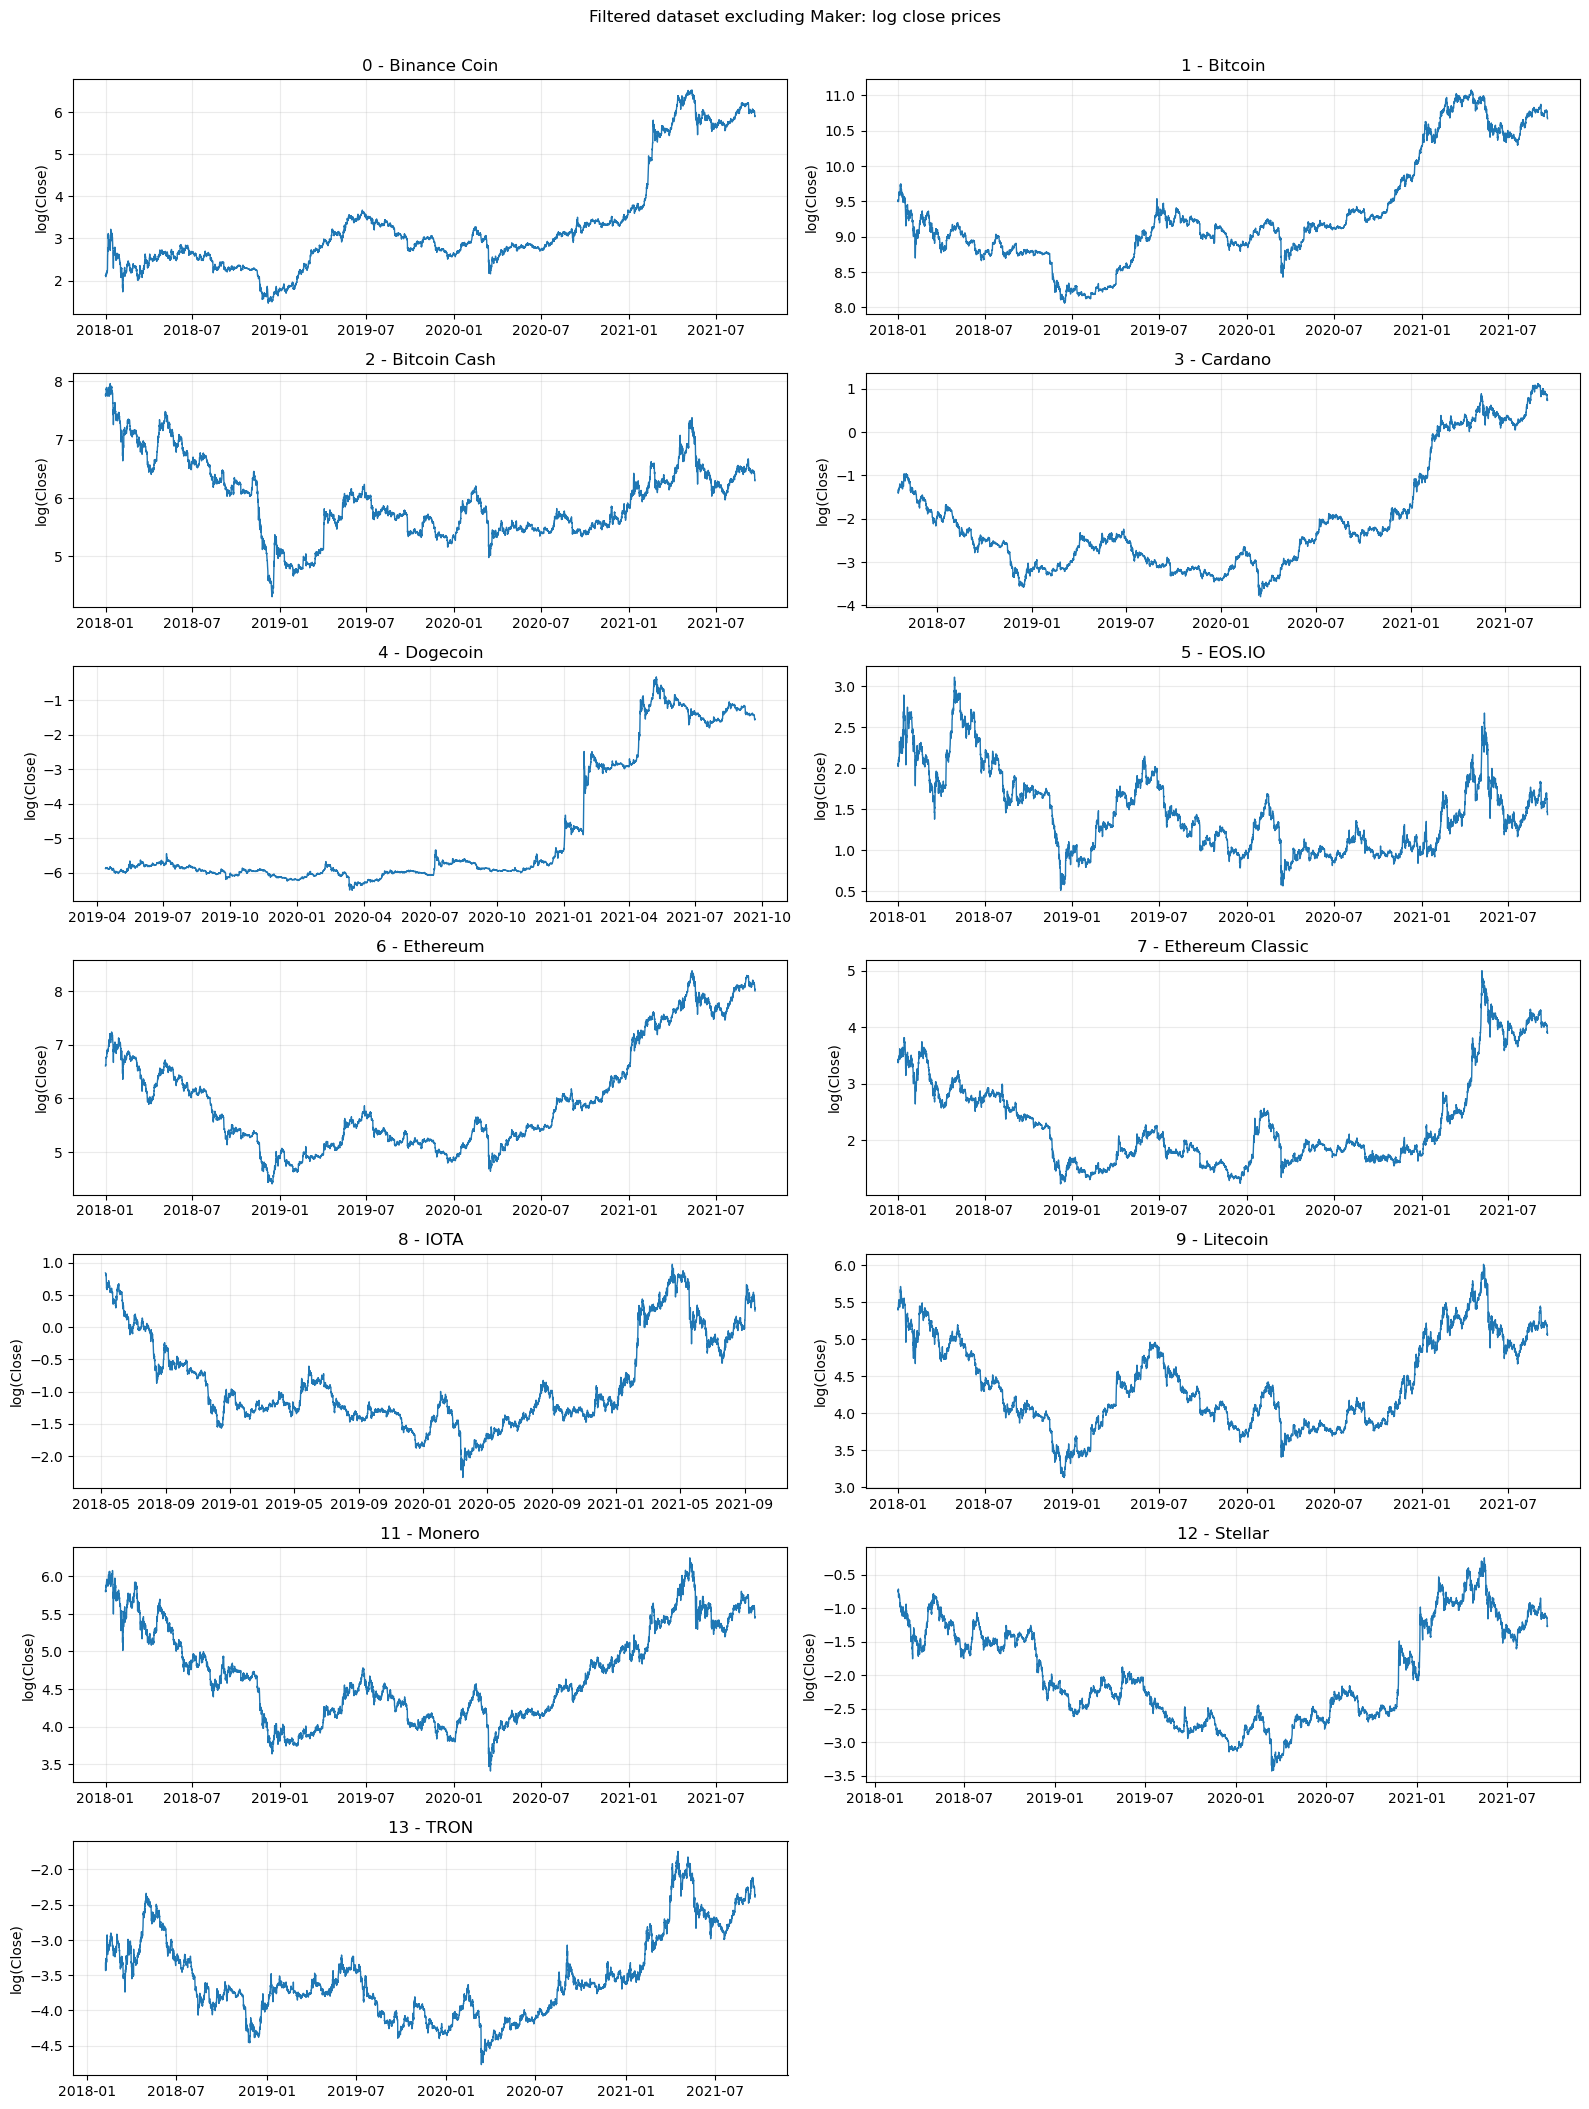


Log-price stationarity tests:
 Asset_ID       Asset_Name  Variable  n_obs ADF regression  ADF lag BIC  ADF statistic  ADF p-value KPSS regression  KPSS lags auto  KPSS statistic  KPSS p-value  PP lags  PP statistic  PP p-value           Decision
        0     Binance Coin Log_Close   8140             ct            7      -1.178710     0.914775              ct              55        2.018606          0.01       37     -1.310490    0.885310 unit-root evidence
        1          Bitcoin Log_Close   8154             ct            7      -2.279416     0.445367              ct              55        2.301868          0.01       37     -2.320649    0.422564 unit-root evidence
        2     Bitcoin Cash Log_Close   8154             ct            6      -2.537698     0.309378              ct              55        2.290753          0.01       37     -2.597734    0.280937 unit-root evidence
        3          Cardano Log_Close   7516             ct            6      -1.459656     0.842541      

In [4]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

print('\n--- RIGOROUS STATIONARITY DIAGNOSTICS ---')
print('ADF H0: unit root. KPSS H0: stationarity around the chosen deterministic terms.')
print('ADF lag length is selected with BIC, not the default AIC.')
print(f'Stationarity diagnostics are run on the filtered modeling dataset: {df["Asset_Name"].nunique()} assets, {len(df):,} rows.')

# Work on a copy so that this diagnostic block is reproducible and does not silently mutate earlier EDA results.
stationarity_df = df.copy()
stationarity_df['Log_Close'] = np.log(stationarity_df['Close'])
stationarity_df['Log_Return'] = stationarity_df.groupby('Asset_ID')['Log_Close'].diff()

# 1) Visual diagnostics for deterministic terms.
# Raw prices have very different scales, so a single raw-price plot would be misleading.
# Small multiples with normalized prices preserve each asset's shape and make trend/intercept inspection easier.
assets = stationarity_df[['Asset_ID', 'Asset_Name']].drop_duplicates().sort_values('Asset_ID')
n_assets = len(assets)
ncols = 2
nrows = int(np.ceil(n_assets / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.0 * nrows), sharex=False)
axes = np.ravel(axes)

for ax, (_, asset_row) in zip(axes, assets.iterrows()):
    asset_id = asset_row['Asset_ID']
    asset_name = asset_row['Asset_Name']
    asset_data = stationarity_df[stationarity_df['Asset_ID'] == asset_id].sort_values('timestamp')
    normalized_close = 100 * asset_data['Close'] / asset_data['Close'].iloc[0]

    ax.plot(asset_data['timestamp'], normalized_close, linewidth=1)
    ax.axhline(100, color='black', linewidth=0.8, alpha=0.35)
    ax.set_title(f'{asset_id} - {asset_name}')
    ax.set_ylabel('Close index, first obs = 100')
    ax.grid(alpha=0.25)

for ax in axes[n_assets:]:
    ax.axis('off')

fig.suptitle('Filtered dataset excluding Maker: normalized close prices', y=1.002)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.0 * nrows), sharex=False)
axes = np.ravel(axes)

for ax, (_, asset_row) in zip(axes, assets.iterrows()):
    asset_id = asset_row['Asset_ID']
    asset_name = asset_row['Asset_Name']
    asset_data = stationarity_df[stationarity_df['Asset_ID'] == asset_id].sort_values('timestamp')

    ax.plot(asset_data['timestamp'], asset_data['Log_Close'], linewidth=1)
    ax.set_title(f'{asset_id} - {asset_name}')
    ax.set_ylabel('log(Close)')
    ax.grid(alpha=0.25)

for ax in axes[n_assets:]:
    ax.axis('off')

fig.suptitle('Filtered dataset excluding Maker: log close prices', y=1.002)
plt.tight_layout()
plt.show()

# Deterministic terms for the ADF regression:
# 'n'  = no constant and no trend
# 'c'  = constant only
# 'ct' = constant and deterministic linear trend
# Crypto price levels usually have a non-zero level and visible trends, so 'ct' is the conservative default for log-prices.
# After inspecting the plots above, override individual assets here if the visual evidence supports a simpler specification.
level_adf_regression_by_asset = {asset_id: 'ct' for asset_id in assets['Asset_ID']}

# Returns fluctuate around a roughly constant mean and should not include a deterministic time trend by default.
# We include a constant ('c') because the sample mean is not imposed to be exactly zero.
return_adf_regression_by_asset = {asset_id: 'c' for asset_id in assets['Asset_ID']}

try:
    from arch.unitroot import PhillipsPerron
except ImportError:
    PhillipsPerron = None


def run_stationarity_tests(series, adf_regression):
    """Run ADF with BIC-selected lags, KPSS, and optional Phillips-Perron if arch is installed."""
    x = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()

    # ADF: autolag='BIC' selects the lag order by Bayesian Information Criterion.
    adf_stat, adf_pvalue, adf_lag, adf_nobs, adf_crit, adf_icbest = adfuller(
        x,
        regression=adf_regression,
        autolag='BIC'
    )

    # KPSS supports only 'c' and 'ct'. If the ADF has no constant, use 'c' for a conservative KPSS comparison.
    kpss_regression = 'ct' if adf_regression == 'ct' else 'c'
    try:
        kpss_stat, kpss_pvalue, kpss_lags, kpss_crit = kpss(
            x,
            regression=kpss_regression,
            nlags='auto'
        )
    except Exception as exc:
        kpss_stat, kpss_pvalue, kpss_lags = np.nan, np.nan, np.nan

    if PhillipsPerron is not None:
        pp = PhillipsPerron(x, trend=adf_regression)
        pp_stat, pp_pvalue, pp_lags = pp.stat, pp.pvalue, pp.lags
    else:
        pp_stat, pp_pvalue, pp_lags = np.nan, np.nan, np.nan

    if (adf_pvalue < 0.05) and (pd.isna(kpss_pvalue) or kpss_pvalue >= 0.05):
        decision = 'stationary evidence'
    elif (adf_pvalue >= 0.05) and (pd.isna(kpss_pvalue) or kpss_pvalue < 0.05):
        decision = 'unit-root evidence'
    else:
        decision = 'mixed/inconclusive'

    return {
        'n_obs': len(x),
        'ADF regression': adf_regression,
        'ADF lag BIC': adf_lag,
        'ADF statistic': adf_stat,
        'ADF p-value': adf_pvalue,
        'KPSS regression': kpss_regression,
        'KPSS lags auto': kpss_lags,
        'KPSS statistic': kpss_stat,
        'KPSS p-value': kpss_pvalue,
        'PP lags': pp_lags,
        'PP statistic': pp_stat,
        'PP p-value': pp_pvalue,
        'Decision': decision
    }


results = []
for asset_id, asset_data in stationarity_df.groupby('Asset_ID'):
    asset_name = asset_data['Asset_Name'].iloc[0]

    level_result = run_stationarity_tests(
        asset_data['Log_Close'],
        level_adf_regression_by_asset[asset_id]
    )
    level_result.update({'Asset_ID': asset_id, 'Asset_Name': asset_name, 'Variable': 'Log_Close'})
    results.append(level_result)

    return_result = run_stationarity_tests(
        asset_data['Log_Return'],
        return_adf_regression_by_asset[asset_id]
    )
    return_result.update({'Asset_ID': asset_id, 'Asset_Name': asset_name, 'Variable': 'Log_Return'})
    results.append(return_result)

stationarity_results_df = pd.DataFrame(results)
ordered_cols = [
    'Asset_ID', 'Asset_Name', 'Variable', 'n_obs',
    'ADF regression', 'ADF lag BIC', 'ADF statistic', 'ADF p-value',
    'KPSS regression', 'KPSS lags auto', 'KPSS statistic', 'KPSS p-value',
    'PP lags', 'PP statistic', 'PP p-value', 'Decision'
]

print('\nLog-price stationarity tests:')
print(stationarity_results_df[stationarity_results_df['Variable'] == 'Log_Close'][ordered_cols].to_string(index=False))

print('\nLog-return stationarity tests:')
print(stationarity_results_df[stationarity_results_df['Variable'] == 'Log_Return'][ordered_cols].to_string(index=False))

return_moments = []
for asset_id, asset_data in stationarity_df.dropna(subset=['Log_Return']).groupby('Asset_ID'):
    asset_returns = asset_data['Log_Return'].replace([np.inf, -np.inf], np.nan).dropna()
    return_moments.append({
        'Asset_ID': asset_id,
        'Asset_Name': asset_data['Asset_Name'].iloc[0],
        'Mean': asset_returns.mean(),
        'Std': asset_returns.std(),
        'Skewness': skew(asset_returns),
        'Excess Kurtosis': kurtosis(asset_returns)
    })

return_moments_df = pd.DataFrame(return_moments)
print('\nLog-return distribution moments:')
print(return_moments_df.to_string(index=False))
print('\nNote: positive excess kurtosis indicates fat tails; normal models underestimate tail risk.')

# Keep a cleaned return dataframe for the following return-based EDA cells, without overwriting df.
returns_df = stationarity_df.dropna(subset=['Log_Return']).copy()


## Interpretation of the stationarity diagnostics

The stationarity diagnostics are now run on the filtered modeling dataset, after excluding Maker. This is important because the diagnostics should describe the data that will actually feed the model, not an earlier raw version with severe asset-specific gaps.

The log-price results show that price levels remain non-stationary across the remaining assets. ADF generally does not reject the unit-root hypothesis, KPSS rejects stationarity, and Phillips-Perron gives the same broad message. This is consistent with the normalized and log-price plots: crypto prices show persistent trends, crashes, recoveries, and regime shifts.

The log-return results are much more suitable for modeling. ADF and Phillips-Perron strongly reject the unit-root hypothesis for the remaining assets, while KPSS mostly supports stationarity or gives mixed evidence for a few assets. Mixed KPSS results are not unusual in financial data because returns may be stationary in mean while still having changing volatility or structural breaks.

This supports the planned target definition: at the end of candle `t`, use only information available up to `t` to predict whether `log(Close[t+1] / Close[t])` is positive. It also tells us that feature engineering should be based on returns, lagged returns, relative candle measures, rolling volatility, and market-wide return features rather than raw price levels.


In [ ]:
print('\n--- AUTOCORRELATION ANALYSIS (Asset_ID 0 as sample) ---')
sample_returns = returns_df[returns_df['Asset_ID'] == 0]['Log_Return']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(sample_returns, lags=40, ax=axes[0], alpha=0.05)
plot_pacf(sample_returns, lags=40, ax=axes[1], alpha=0.05)
axes[0].set_title('ACF - Asset 0')
axes[1].set_title('PACF - Asset 0')
plt.show()

# Ljung-Box test to check whether residual autocorrelation is significant
lb_test = acorr_ljungbox(sample_returns, lags=[10, 20], return_df=True)
print('Ljung-Box test (H0: observations are independently distributed):')
print(lb_test)
print('\n--- VISUAL INSPECTION ---')

## Interpretation of the autocorrelation output

For Binance Coin, the Ljung-Box test strongly rejects the null hypothesis that returns are independently distributed at both 10 and 20 lags. The ACF and PACF plots therefore matter: they help us see whether the dependence is concentrated at short lags or spread across several lags.

This output suggests that lagged returns may be useful as features, but we should be careful not to overstate the conclusion from one asset. A later version of the EDA should repeat the autocorrelation check across all assets and should also examine squared or absolute returns, because volatility clustering is often stronger than raw return autocorrelation in financial data.

The next code cell studies cross-asset return correlations and validates VWAP values. Cross-asset correlations are important because crypto assets often move together; Bitcoin or market-wide returns may be useful predictors. VWAP validation is important because corrupted VWAP values can contaminate engineered features such as price deviation from VWAP.


In [ ]:
print('\n--- CROSS-ASSET CORRELATION ANALYSIS ---')
# Pivot to get parallel time series of log returns per asset
returns_pivot = returns_df.pivot(index='timestamp', columns='Asset_ID', values='Log_Return').dropna()

# Spearman rank correlation to capture monotonic relationships
corr_matrix = returns_pivot.corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Rank Correlation Matrix (Log-Returns)')
plt.show()

print('\n--- VWAP vs HIGH/LOW VALIDATION ---')
# VWAP must be inside [Low, High]; if not, the observation is corrupted
corrupted_vwap = df[(df['VWAP'] < df['Low']) | (df['VWAP'] > df['High'])]
print(f'Rows with VWAP outside [Low, High]: {len(corrupted_vwap)} out of {len(df)}')

## Interpretation of cross-asset correlations and VWAP validation

The return correlation heatmap shows that crypto assets are positively correlated, which indicates a strong common market factor. This supports adding market-level features later, such as Bitcoin return, Ethereum return, or an equal-weighted crypto market return computed at the same timestamp using only available information.

The VWAP validation identifies 10 rows where VWAP lies outside the candle range. Since VWAP should normally be between Low and High, these observations are likely corrupted or affected by data issues. This matters because VWAP-based features would inherit those errors. Before modeling, we should replace invalid or infinite VWAP values with missing values and either impute them carefully or avoid VWAP-derived features for those rows.

The next analytical steps should be: clean invalid VWAP values, decide whether Maker is excluded from the main experiment, create the future 4-hour return target, inspect target balance by asset, and engineer lagged/rolling features from stationary transformations rather than raw price levels.
